---
title: "Mapping world population density"
description: Global population density maps built with xarray and plotnine.
date: "2025-11-04"
categories: [Data Visualization, Python, GIS, plotnine, xarray]
image: featured_map.png
author: Alejandro Fontal

---

In this post I explore where people actually live by translating the Global Human Settlement Layer into a set of clean, plotnine-ready datasets. We will pull the 2025 population grid, reshape it with xarray, and engineer a composite visualization that highlights both the geographic hotspots and the latitudinal/longitudinal population profiles. Along the way I will share the small plotting hacks that make the final figure publication-ready.

### Preamble

#### Imports

In [1]:
import textwrap
import xarray as xr
import plotnine as p9
import rasterio as rio

from PIL import Image
from io import BytesIO
from mizani.transforms import log1p_trans
from plotnine.composition import plot_spacer, plot_layout, plot_annotation

#### Plotting pre-sets

In [6]:
import matplotlib.pyplot as plt
import matplotlib_inline

# Matplotlib settings
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
plt.rcParams['figure.dpi'] = 600

# Plotnine settings (for figures)

p9.options.set_option('base_family', 'monospace')

p9.theme_set(
    p9.theme_bw()
    + p9.theme(panel_grid=p9.element_blank(),
               legend_background=p9.element_blank(),
               panel_grid_major=p9.element_line(size=.5, linetype='dashed',
                                                alpha=.15, color='black'),
               plot_title=p9.element_text(ha='center'),
               dpi=600
    )
)

I will download the GHS (Global Human Settlement) population density dataset at 1km resolution,
particularly the 2025 projection. 

You can find it here to download manually choosing your desired resolution and coordinate system: 

https://human-settlement.emergency.copernicus.eu/download.php?ds=pop

In my case, I have downloaded the full world file at 1km resolution (~300 MB) and unzipped it in a local folder.

In [ ]:
filename = "GHS_POP_E2025_GLOBE_R2023A_54009_1000"
ftp_url = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata"
!mkdir -p .tmp
!wget "{ftp_url}/GHSL/GHS_POP_GLOBE_R2023A/{filename}/V1-0/{filename}_V1_0.zip" \
    -O ".tmp/{filename}.zip"
    
!mkdir -p tmp/{filename}/
!unzip -o ".tmp/{filename}.zip" -d ".tmp/{filename}/"

We can now read the `.tif` file using `xarray` with the `rasterio` engine. 

To make the processing faster, and since the visualization won't really benefit from a 1km resolution unless
extremely zoomed in, I will coarse the data to approximately 10km resolution by summing 10x10 pixel blocks.

In [ ]:
download_path = '.tmp/'
tif_path = f'{download_path}/{filename}/{filename}_V1_0.tif'
raster_datarray= xr.open_dataset(tif_path, engine='rasterio').squeeze(drop=True)
factor = 10                                 # 10 * res ≈ 10 km pixels if res is 1000 m
d_coarse = raster_datarray.coarsen(y=factor, x=factor, boundary="trim").sum()
d_ll = d_coarse.rio.reproject("EPSG:4326", resampling=rio.enums.Resampling.average)
density_raster_df = (d_ll
                     .to_dataframe()
         .reset_index()
         .drop(columns='spatial_ref')
         .dropna()
         .rename(columns={'band_data': 'population_density'})
         # There's 0 population recorded below -60 latitude so to improve visualization 
         # we'll just filter out everything below that
         .query('y >= -60')
)

The only "cool" part of this visualization will be to use the newly added plot composition features of Plotnine to
create latitude and longitude marginal plots showing the summed population densities along those axes.

I will generate a 0.5° bin for each axis, which should be enough to see the main trends without losing too much detail:

In [8]:
# Profiles
lat_profile = (d_ll.sum(dim="x")
                 .to_dataframe()
                 .rename(columns={"band_data": "total_pop"})
                 .reset_index()
                 .rename(columns={"y": "lat"}))

lon_profile = (d_ll.sum(dim="y")
                 .to_dataframe()
                 .rename(columns={"band_data": "total_pop"})
                 .reset_index()
                 .rename(columns={"x": "lon"}))

smooth_lat_profile = (lat_profile
                    .fillna(0)
                    # round to the nearest 0.5 degree
                    .assign(lat=lambda dd: dd.lat.apply(lambda x: round(x * 2) / 2))
                    .groupby('lat', as_index=False)
                    ['total_pop'].sum()
                    .query('lat >= -60')
                    )

smooth_lon_profile = (lon_profile
                    .fillna(0)
                    # round to the nearest 0.5 degree
                    .assign(lon=lambda dd: dd.lon.apply(lambda x: round(x * 2) / 2))
                    .groupby('lon', as_index=False)
                    ['total_pop'].sum()
                    # .query('lon >= -180')
                    )

Now, with all the data prepared, we just need to create the plots and compose them together.

Unfortunately, at the time of writing this, Plotnine does not support composing plots with different widths and heights,
so I will have to hack around this by manually adjusting the subplot margins and adding empty spacers.

To move the axis lines to the top and right,I also will have to drop down to `matplotlib` calls, as `plotnine` does not support this yet (although it is planned for future releases, see [#121](https://github.com/has2k1/plotnine/issues/121)).

If we do all that:

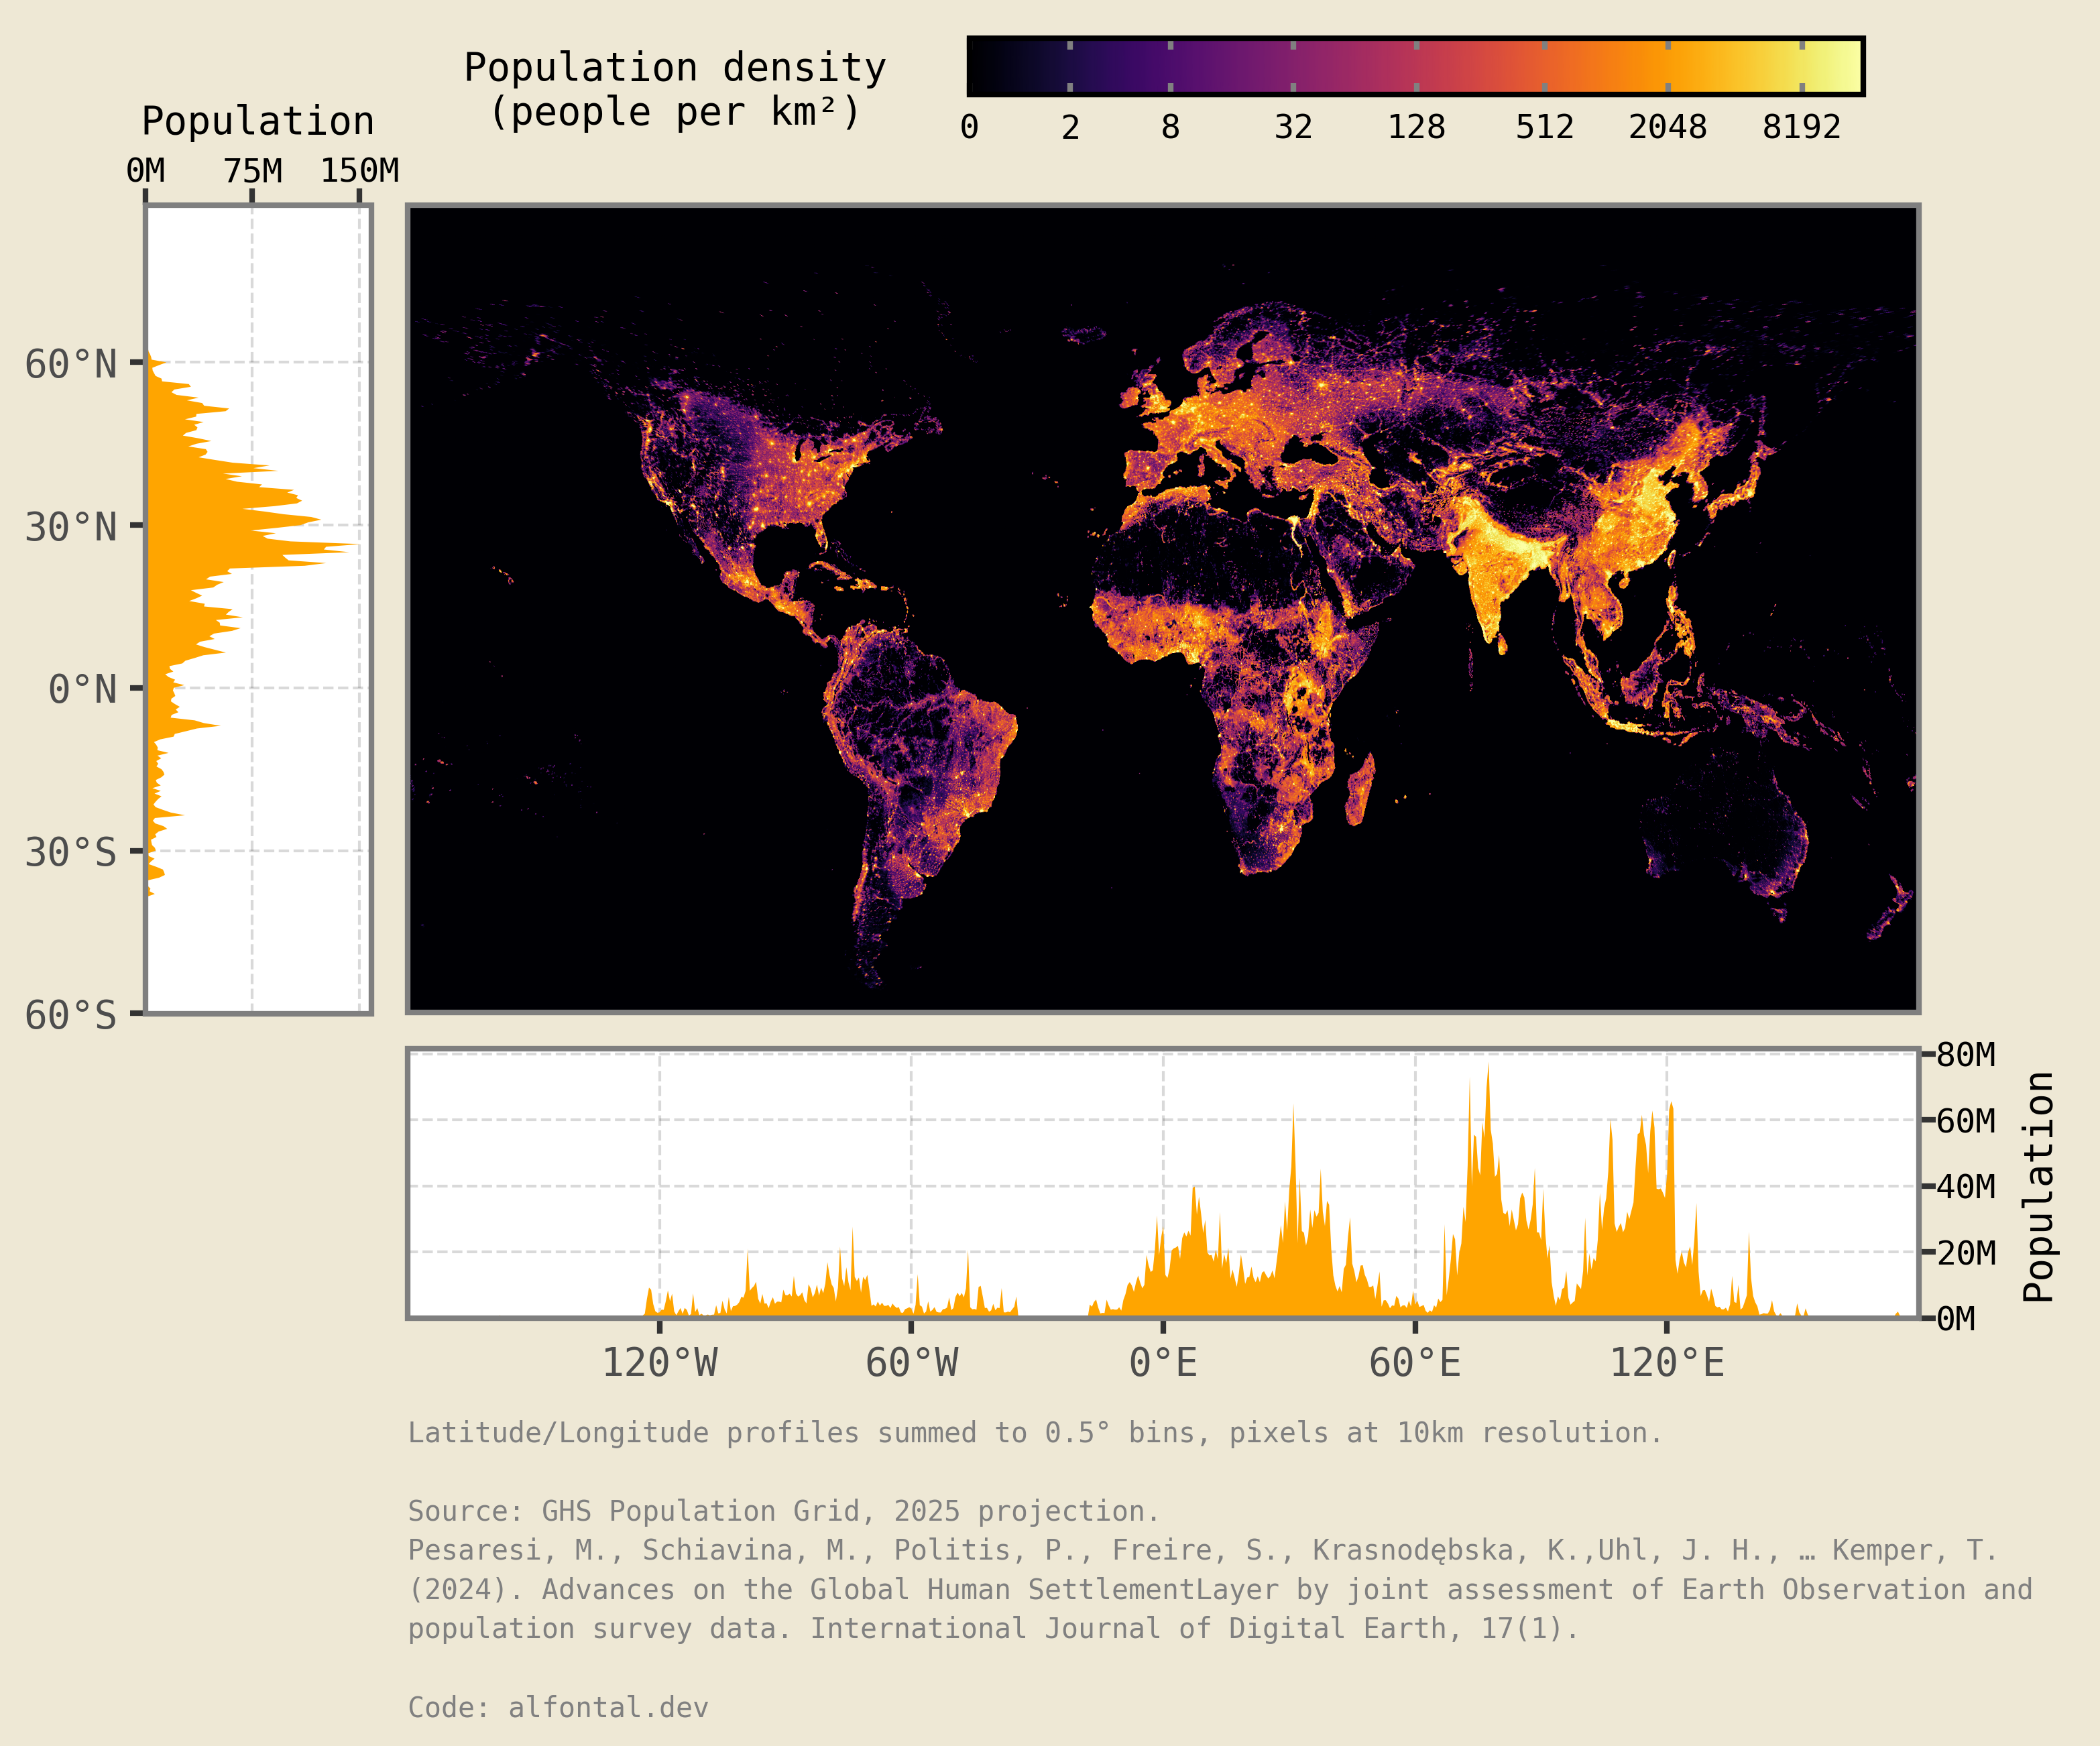

In [ ]:
#| column: body-outset 
caption_str = \
'Latitude/Longitude profiles summed to 0.5° bins, pixels at 10km resolution.\n\n' + \
'Source: GHS Population Grid, 2025 projection.\n' + \
 textwrap.fill(
        'Pesaresi, M., Schiavina, M., Politis, P., Freire, S., Krasnodębska, K.,' +
        'Uhl, J. H., … Kemper, T. (2024). Advances on the Global Human Settlement' +
        'Layer by joint assessment of Earth Observation and population survey data. ' +
        'International Journal of Digital Earth, 17(1).', width=99) + \
        '\n\nCode: alfontal.dev'



def custom_label_lat(breaks):
    return [f"{x:.0f}°N" if x >= 0 else f"{abs(x):.0f}°S" 
            for x in breaks]

def custom_label_lon(breaks):
    return [f"{x:.0f}°E" if x >= 0 else (f"{abs(x):.0f}°W" if x > -180 else '') 
            for x in breaks]

hi = density_raster_df.population_density.apply(lambda x: x / 10).quantile(0.999)
breaks = [0] + [2**i for i in range(15) if i % 2 != 0]

latitude_kwargs = dict(
     limits=(-60 * 1.001, lat_profile.lat.max() * 1.001),
     labels=custom_label_lat,
     expand=(.0, .0),
     breaks=range(-60, 90, 30),
     )

longitude_kwargs = dict(
     breaks=range(-120, 180, 60),
     labels=custom_label_lon,
     limits=(-180, 180),
     expand=(.0, .0),
)


world_map = (p9.ggplot(density_raster_df)
 + p9.aes(x='x', y='y', fill='population_density / 10 + 1e-5')
 + p9.geom_raster()
 + p9.scale_fill_continuous(
      'inferno',
      trans=log1p_trans(),
      limits=(0, hi),
      breaks=breaks,
      labels=[f"{b:g}" for b in breaks],
      na_value="black"
  )
 + p9.scale_y_continuous(**latitude_kwargs)
 + p9.scale_x_continuous(**longitude_kwargs)
 + p9.labs(x='', y='', fill='Population density\n(people per km²)')
 + p9.theme(
     figure_size=(8, 5),
     legend_position=(.5, 1.25),
     legend_frame=p9.element_rect(size=1, color="black"),
     legend_ticks=p9.element_line(size=1, color="gray"),
     legend_key_width=160,
     legend_key_height=10,
     legend_direction='horizontal',
     axis_text=p9.element_blank(),
     axis_ticks=p9.element_blank(),
     plot_margin_left=0.01,
     )
)

lat_plot = (p9.ggplot(smooth_lat_profile)
    + p9.aes(x='lat', y='total_pop')
    + p9.geom_area(fill='orange')
    + p9.labs(x='Latitude', y='')
    + p9.scale_fill_continuous('inferno')
    + p9.guides(fill=False)
    + p9.coord_flip()
    + p9.scale_y_continuous(
        expand=(.0, .0), 
        limits=(0, smooth_lat_profile.total_pop.max() * 1.05),
        labels=lambda x: [ f'{i/1e6:.0f}M' for i in x],
        breaks=[0, 75e6, 150e6],
        )
    + p9.scale_x_continuous(**latitude_kwargs)
    + p9.theme(
             axis_text_x=p9.element_blank(),
             axis_ticks_x=p9.element_blank(),
             axis_text_y=p9.element_text(size=7),
             plot_margin_left=.15,
             plot_margin_right=0,
             plot_margin_top=.15,
             plot_margin_bottom=.175
         )
)

lon_plot = (p9.ggplot(smooth_lon_profile)
        + p9.aes(x='lon', y='total_pop')
        + p9.geom_area(fill='orange')
        + p9.scale_fill_continuous('inferno')
        + p9.guides(fill=False)
        + p9.labs(x='', y='', caption=caption_str
        )
        + p9.scale_y_continuous(
                    expand=(0, 0), 
                    limits=(0, smooth_lon_profile.total_pop.max() * 1.05),
                    labels=lambda x: [ f'{i/1e6:.0f}M' for i in x ],
                    )
        + p9.scale_x_continuous(**longitude_kwargs)
        + p9.theme(
        plot_margin_top=.0,
        plot_margin_bottom=.06,
        plot_margin_right=.05, # need to make space for y axis label we'll add later
        axis_text_y=p9.element_blank(),
        axis_ticks_y=p9.element_blank(),
        axis_text_x=p9.element_text(size=7)
          )
)
ps = plot_spacer()
left_panel = ((ps | ps | ps |  ps | lat_plot) / (ps / ps))
bottom_panel = (lon_plot / ps / ps)
final_plot = (left_panel | world_map / bottom_panel) & p9.theme(
    figure_size=(9, 7),
    legend_title=p9.element_text(size=7, linespacing=1.2),
    legend_text=p9.element_text(size=6),
    plot_background=p9.element_rect(fill='#EEE8D5', color='#EEE8D5'),
    plot_caption=p9.element_text(size=5, ha='left', color='gray', linespacing=1.5)
    )

# We can't change axis label positions directly in plotnine, so we'll do it
# using matplotlib after drawing the figure:


# The trick with the spacers works, but the figure is barely occupying ±40%
#  of the total plot area, with white space all around.
# I'll do the last hack to crop the image and display it directly using PIL:

buf = BytesIO()
f.savefig(buf, format='png', dpi=600)
buf.seek(0)
img = Image.open(buf)
w, h = img.size
crop_pct = (.42, .12, 1, 0.74)  # left, top, right, bottom as fractions of width/height
crop_box = (crop_pct[0] * w, crop_pct[1] * h, crop_pct[2] * w, crop_pct[3] * h)
cropped = img.crop(crop_box)
display(cropped)

And voilà, there we have it, a world population density plot with latitude and longitude marginals!